In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
import torch
import pickle as pkl
import ast
import argparse

from Model.MENDR.SpatialTemporalEncoder import SpatialTemporalEncoder
from Model.MENDR.MENDRContextualizer import mATTContextualizer
from Model.MENDR.MENDRTrainer import MENDRTrainer
from Model.encoder import ConvEncoder
from Model.MENDR.R2E import R2E
from Model.transforms import RandomTemporalCrop
from Model.TrainingDecoder.WaveletDecoder import WaveletDecoder
from dataset import EEGDataset
import matplotlib.pyplot as plt

In [3]:
# Open the file in read binary mode
with open('/home/hice1/mchen439/scratch/models/model_f9a1588732d247adbf336433917ae34a.pkl', 'rb') as file:
    # Load the pickled data from the file
    model = pkl.load(file)

In [5]:
# setup arg parser
parser = argparse.ArgumentParser()

# Training Parameters
parser.add_argument(
    "--random_state", type=int, help="Random state for reproducibility", default=42
)
parser.add_argument(
    "-b", "--batch_size", default=32, type=int, help="mini-batch size (default: 32)"
)

parser.add_argument(
    "-e", "--training_epochs", default=1, type=int, help="number of total training epochs (default: 1)"
)

parser.add_argument(
    "--train_frac", type=float, help="Fraction of dataset to use for training", default=1.0
)

parser.add_argument(
    "--val_frac", type=float, help="Fraction of dataset to use for validation", default=0.0
)

# Spatial Temporal Embedding Encoder Configs
parser.add_argument(
    "--seq_len", type=int, help="Sequence Length of Recordings", default=15360
)

parser.add_argument(
    "--pred_len", type=int, help="Prediction Length of Recordings, should be equal to sequence length",  default=15360
)

parser.add_argument(
    "--top_k", type=int, help="Top K frequencies to select in TimesBlock", default=3
)

parser.add_argument(
    "--d_model", type=int, help="Number of EEG Channels", default=19
)

parser.add_argument(
    "--d_ff", type=int, help="Feed Forward Dimension in TimesBlock", default=5
)

parser.add_argument(
    "--num_kernels", type=int, help="Number of Kernels in Convolutional Layer of Inception Block in TimesBlock", default=1
)

parser.add_argument(
    "--num_heads", type=int, help="Number of Heads in Multihead Attention Layer of GAT",  default=2
)

parser.add_argument(
    "--ste_dropout", type=float, help="Dropout Rate for GAT", default=0.1
)

# Encoder Configs
parser.add_argument(
    "--encoder_h", type=int, help="Hidden Dimension of Encoder", default=32
)

parser.add_argument(
    "--enc_width", type=ast.literal_eval, help="Encoder Width", default=(3, 2, 2, 2)
)

parser.add_argument(
    "--enc_downsample", type=ast.literal_eval, help="Encoder Downsample", default=(3, 2, 2, 2)
)

parser.add_argument(
    "--enc_dropout", type=float, help="Dropout Rate for Encoder", default=0.1
)

# MENDR Contextualizer Configs
parser.add_argument(
    "--in_features", type=int, help="Input Features for Contextualizer", default=32
)

parser.add_argument(
    "--dropout", type=float, help="Dropout Rate for Contextualizer", default=0.1
)

parser.add_argument(
    "--position_encoder", type=int, help="Position Encoder", default=25
)

parser.add_argument(
    "--epochs", type=int, help="Number of Epochs for mATT", default=4
)

# Trainer Configs
parser.add_argument(
    "--mask_span", type=int, help="Mask Span", default=10
)

parser.add_argument(
    "--mask_rate", type=float, help="Mask Rate", default=0.065
)

parser.add_argument(
    "--multi_gpu", type=bool, help="Multi GPU Training", default=False
)

parser.add_argument(
    "--encoder_grad_frac", type=float, help="Encoder Gradient Fraction", default=1
)

parser.add_argument(
    "--learning_rate", type=float, help="Learning Rate", default=0.1
)

parser.add_argument(
    "--l2_weight_decay", type=float, help="L2 Weight Decay. Helps with generalization", default=1e-5
)

parser.add_argument(
    "--temp", type=float, help="Temperature", default=0.1
)

parser.add_argument(
    "--enc_feat_l2", type=float, help="Encoder Feature L2", default=1e-5
)

parser.add_argument(
    "--num_negatives", type=int, help="Number of Negatives in Contrastive Learning Task", default=20
)

parser.add_argument(
    "--max_crop_frac", type=float, help="Maximum Crop Fraction on Random Temporal Crop", default=0.05
)

parser.add_argument(
    "--permuted_encodings", type=bool, help="Permuted Encodings", default=False
)

parser.add_argument(
    "--permuted_contexts", type=bool, help="Permuted Contexts", default=False
)

parser.add_argument(
    "--save_model", type=bool,
    help="Whether to save model.", default=False
)

parser.add_argument(
    "--save_model_directory", type=str, help="If save model is true, specifies where to save it", required=False
)

# parse args
args, unknown_args = parser.parse_known_args()



In [9]:
### Model ###
stEncoder = SpatialTemporalEncoder(args)
encoder = ConvEncoder(in_features=args.d_model, encoder_h=args.encoder_h, 
                    enc_width=args.enc_width, dropout=args.enc_dropout, enc_downsample=args.enc_downsample)
contextualizer = mATTContextualizer(args)
r2e = R2E(args)

decoder = WaveletDecoder(encoder_h=args.encoder_h,
                    out_features=args.d_model, 
                    enc_width=args.enc_width[::-1],
                    enc_downsample=args.enc_downsample[::-1],
                    original_time_len=args.seq_len)

trainer = MENDRTrainer(stEncoder, encoder, contextualizer, r2e, decoder, args)
print("Total number of parameters: ", sum(p.numel() for p in trainer.parameters() if p.requires_grad))

trainer.set_optimizer(torch.optim.Adam(trainer.parameters()))
trainer.add_batch_transform(RandomTemporalCrop(max_crop_frac=args.max_crop_frac))

GPU(s) detected: training and model execution will be performed on GPU.
Device Properties: _CudaDeviceProperties(name='NVIDIA A100 80GB PCIe', major=8, minor=0, total_memory=81157MB, multi_processor_count=108, uuid=90371dd5-d368-02b6-cb17-88c6701717bc, L2_cache_size=40MB)
Total number of parameters:  969324106


In [10]:
for idx, module in enumerate(model):
    print("Module ", idx)
    for k, v in module.items():
        print(k)

Module  0
tangent.vec.row_idx
tangent.vec.col_idx
Module  1
encoder.Encoder_0.0.weight
encoder.Encoder_0.0.bias
encoder.Encoder_0.2.weight
encoder.Encoder_0.2.bias
encoder.Encoder_1.0.weight
encoder.Encoder_1.0.bias
encoder.Encoder_1.2.weight
encoder.Encoder_1.2.bias
encoder.Encoder_2.0.weight
encoder.Encoder_2.0.bias
encoder.Encoder_2.2.weight
encoder.Encoder_2.2.bias
encoder.Encoder_3.0.weight
encoder.Encoder_3.0.bias
encoder.Encoder_3.2.weight
encoder.Encoder_3.2.bias
Module  2
gnn_layer.conv.att_src
gnn_layer.conv.att_dst
gnn_layer.conv.bias
gnn_layer.conv.lin.weight
gnn_layer.projection.weight
gnn_layer.projection.bias
bn1.weight
bn1.bias
bn1.running_mean
bn1.running_var
bn1.num_batches_tracked
Module  3
Module  4
delta_decoder.0.weight
delta_decoder.0.bias
delta_decoder.1.weight
delta_decoder.1.bias
delta_decoder.3.weight
delta_decoder.3.bias
theta_decoder.0.weight
theta_decoder.0.bias
theta_decoder.1.weight
theta_decoder.1.bias
theta_decoder.3.weight
theta_decoder.3.bias
alpha_d

0. Encoder
1. Decoder
2. Loss_FN
3. Embedder
4. contextualizer
5. r2e

In [11]:
trainer._trainables = ['r2e', 'encoder', 'embedder', 'loss_fn', 'decoder', 'contextualizer']

In [12]:
trainer.load_best(model)

In [13]:
dataset = EEGDataset(root="/home/hice1/mchen439/data/TUH-Processed/", frac=0.0001)
print("Dataset Length:", len(dataset))

Loading 1 subjects


100%|██████████| 1/1 [00:00<00:00, 20.37it/s]

Dataset Length: 20


In [14]:
inputs, outputs = trainer.predict(dataset=dataset, batch_size=32)

Predicting: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:22<00:00, 22.23s/it]


In [15]:
print(len(inputs), len(outputs), outputs[3].shape, inputs[0].shape)

1 10 torch.Size([20, 19, 246]) torch.Size([20, 19, 15360])


In [17]:
inputs_first_epoch = inputs_firstbatch[0]
outputs_first_epoch = output_firstbatch[0]
print(inputs_first_epoch.shape, outputs_first_epoch.shape)

torch.Size([19, 15360]) torch.Size([19, 246])


In [17]:
inputs_first_epoch_channel = inputs_first_epoch[2].numpy()
outputs_first_epoch_channel = outputs_first_epoch[2].numpy()
assert inputs_first_epoch_channel.shape == outputs_first_epoch_channel.shape

In [19]:
import ptwt

dbt_dwpt = ptwt.WaveletPacket(inputs_first_epoch,
							   wavelet='db4',
							   mode='reflect',
							   maxlevel=6,
							   axis=-1)
 

In [20]:
og_dict = {
		'delta': dbt_dwpt['aaaaaa'],
		'theta': dbt_dwpt['aaaaad'],
		'alpha': dbt_dwpt['aaaad'],
		'beta': dbt_dwpt['aaad'],
		'gamma': dbt_dwpt['aad'],
		'other': dbt_dwpt['ad'],
		'high': dbt_dwpt['d']
}


In [25]:
print(og_dict['delta'].shape, outputs[3][0].shape)

torch.Size([19, 246]) torch.Size([19, 246])


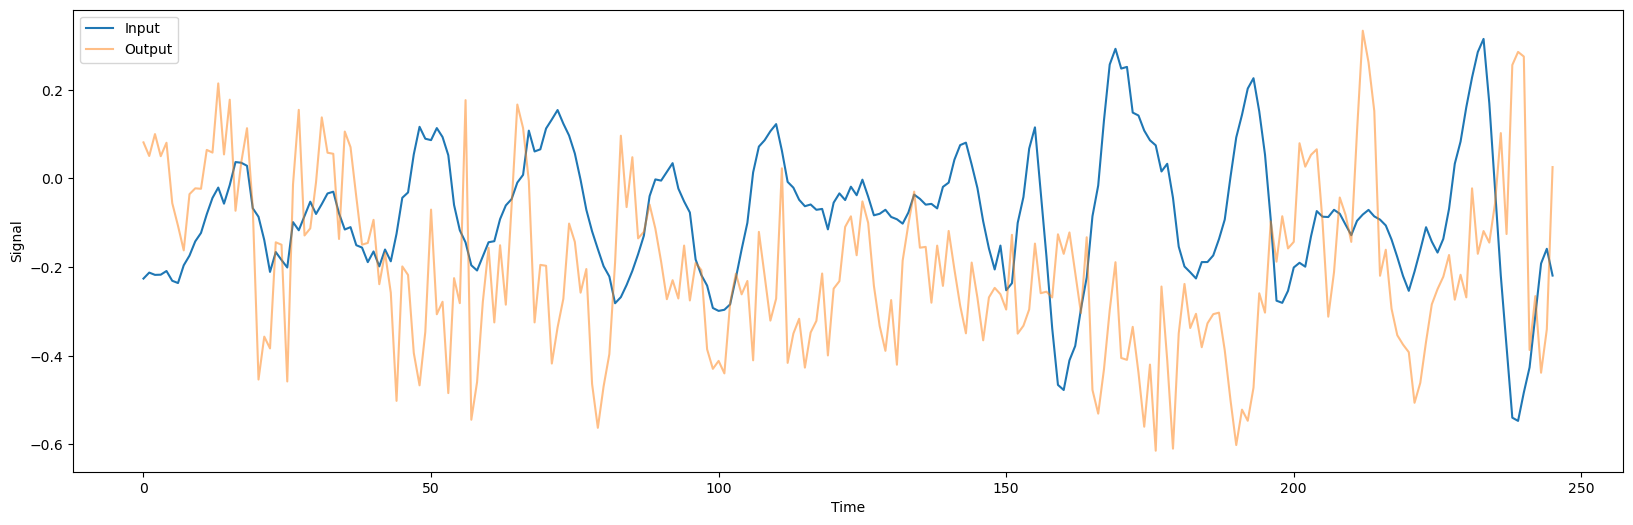

In [37]:
plt.figure(figsize=(20,6))
idx = 10
plt.plot(og_dict['delta'][idx], label="Input")
plt.plot(outputs[3][0][idx], label="Output", alpha=0.5)
plt.xlabel("Time")
plt.ylabel("Signal")
plt.legend()
plt.show()

In [32]:
print("MSE:", ((inputs_first_epoch_channel - outputs_first_epoch_channel).mean())**2)

MSE: 6.473720606348446e-05


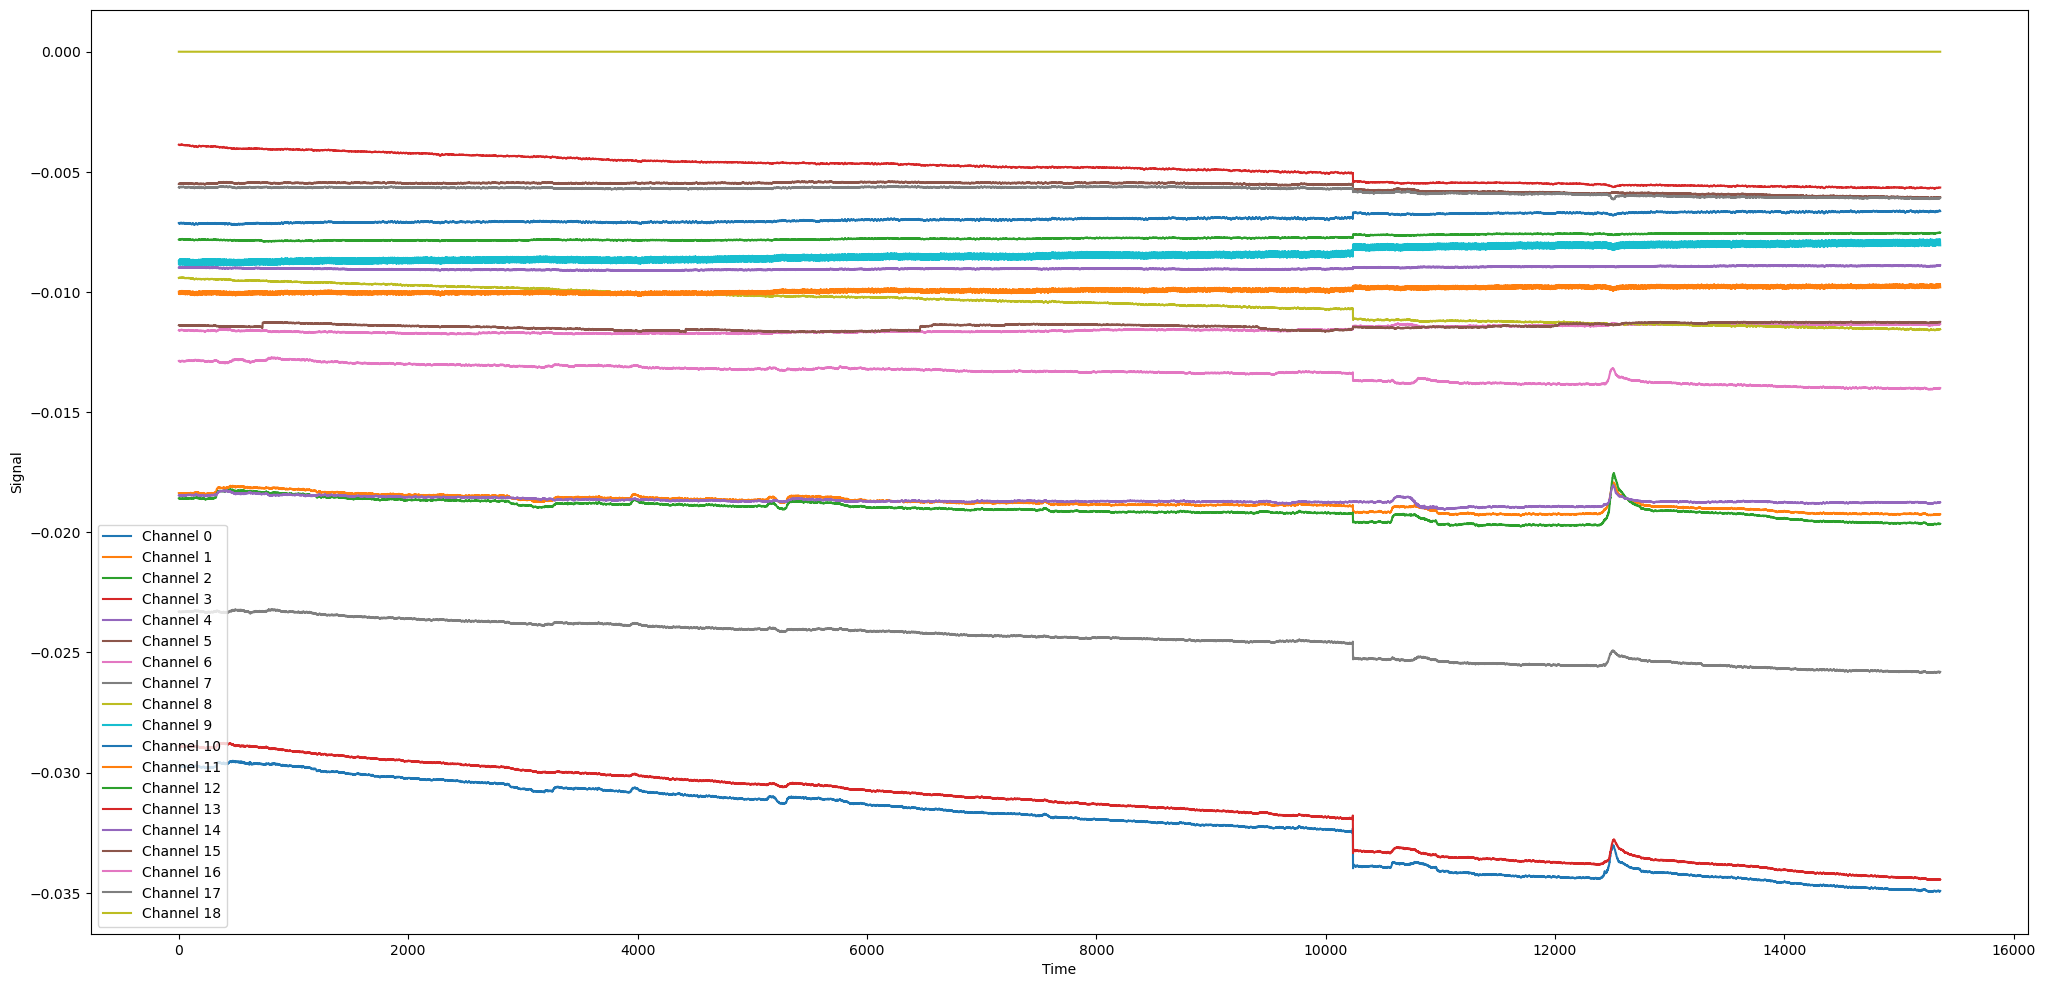

In [67]:
plt.figure(figsize=(25,12))
for i in range(inputs_first_epoch.shape[0]):
    plt.plot(inputs_first_epoch[i], label=f"Channel {i}")
    #plt.plot(outputs_first_epoch[i], label=f"Channel {i} Recon", alpha=0.2)
plt.xlabel("Time")
plt.ylabel("Signal")
plt.legend()
plt.show()